# 第 5 讲：数字控制——采样、执行器、饱和与噪声

前几讲主要在连续时间模型上设计 $K$。但代码运行在数字计算机中，传感器和电机也有自己的动态。一个连续时间上很漂亮的控制器，可能因为采样太慢、执行器跟不上、积分饱和或噪声而失败。

本讲目标：

1. 区分物理积分步长和控制周期；
2. 理解采样与零阶保持；
3. 推导一个简单速度环的离散稳定条件；
4. 理解为什么 500 Hz 的内环参数不能原样搬到 50 Hz；
5. 实践限幅、积分抗饱和和低通滤波。

In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
from scipy.signal import cont2discrete

plt.style.use("seaborn-v0_8-bright")
np.set_printoptions(precision=5, suppress=True)
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((name for name in ["Arial Unicode MS", "PingFang HK", "Noto Sans CJK SC", "SimHei"] if name in available_fonts), "DejaVu Sans")
plt.rcParams.update({"font.sans-serif": [chinese_font], "axes.unicode_minus": False})


## 1. 系统里有两只钟

MuJoCo XML 的积分步长是 0.0005 s，即物理引擎每秒积分 2000 次。教程中的控制周期是 0.02 s，即控制器每秒只更新 50 次。两者不矛盾：

- 物理积分步长决定数值求解运动方程的精细程度；
- 控制周期决定多久读一次传感器并更新一次命令；
- 两次控制更新之间，上一条命令保持不变。

因此，不能因为仿真以 2000 Hz 积分，就声称控制器运行在 2000 Hz。

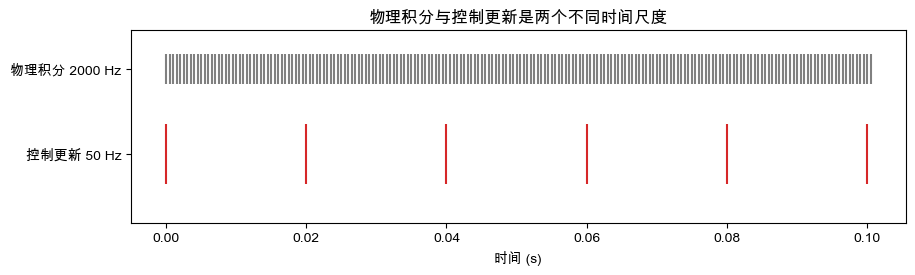

In [2]:
physics_dt = 0.0005
control_dt = 0.02
physics_times = np.arange(0, 0.101, physics_dt)
control_times = np.arange(0, 0.101, control_dt)

plt.figure(figsize=(10, 2.5))
plt.eventplot([physics_times, control_times], lineoffsets=[1, 0],
              linelengths=[0.35, 0.7], colors=["gray", "tab:red"])
plt.yticks([0, 1], ["控制更新 50 Hz", "物理积分 2000 Hz"])
plt.xlabel("时间 (s)")
plt.title("物理积分与控制更新是两个不同时间尺度")
plt.show()


## 2. 从连续模型到离散模型

若控制量在一个周期内保持不变，连续模型

$$\dot x=Ax+Bu$$

可以精确转换为离散模型

$$x[k+1]=A_dx[k]+B_du[k]$$

其中 $A_d=e^{AT_s}$，$B_d=\int_0^{T_s}e^{A\tau}B\,d\tau$。下面用 SciPy 完成零阶保持离散化。

In [3]:
a, b, h, m, g, speed = 0.117, 0.271, 0.292, 5.0, 9.81, 2.0
Ib = 4.0 / 3.0 * m * h**2
a1 = m * a * h * speed / (b * Ib)
a2 = m * speed**2 * h / (b * Ib)
a4 = m * g * h / Ib
A = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.0], [a2, a4, 0.0]])
B = np.array([[1.0], [0.0], [a1]])
C = np.eye(3)
D = np.zeros((3, 1))
Ad, Bd, _, _, _ = cont2discrete((A, B, C, D), control_dt, method="zoh")
print("Ad =\n", Ad)
print("Bd =\n", Bd)
print("开环离散极点 =", np.linalg.eigvals(Ad))
print("离散稳定要求 |z|<1；是否满足？", np.all(np.abs(np.linalg.eigvals(Ad)) < 1))


Ad =
 [[1.      0.      0.     ]
 [0.00759 1.00504 0.02003]
 [0.7595  0.50479 1.00504]]
Bd =
 [[0.02   ]
 [0.00049]
 [0.05202]]
开环离散极点 = [1.10561 0.90448 1.     ]
离散稳定要求 |z|<1；是否满足？ False


连续极点 $p$ 与采样后极点 $z$ 的关系是 $z=e^{pT_s}$。连续稳定极点的实部为负，因此映射到单位圆内部；但这只描述理想的精确离散模型。若存在额外一拍延迟、执行器动态或使用不合适的数值近似，稳定裕度还会下降。

## 3. 为什么速度环增益必须随周期重新检查

考虑最简单的电机速度模型：

$$I\dot\omega=\tau,\qquad \tau=k_p(\omega_r-\omega)$$

用周期 $T_s$ 的前向欧拉更新：

$$\omega[k+1]=(1-k_pT_s/I)\omega[k]+(k_pT_s/I)\omega_r$$

要让误差衰减，需要

$$|1-k_pT_s/I|<1\quad\Rightarrow\quad0<k_p<2I/T_s$$

控制周期增大 10 倍时，允许的比例增益上界缩小到原来的十分之一。这正是项目把转向速度环 `Kp` 从 0.1 调到 0.01 的原因。

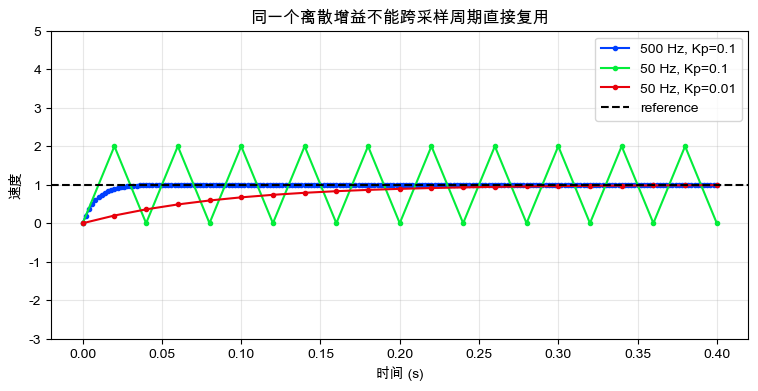

In [4]:
def simulate_velocity_loop(sample_time, kp, inertia=0.001, duration=0.4):
    steps = int(round(duration / sample_time)) + 1
    time = np.arange(steps) * sample_time
    omega = np.zeros(steps)
    reference = 1.0
    for k in range(steps - 1):
        torque = kp * (reference - omega[k])
        omega[k + 1] = omega[k] + sample_time * torque / inertia
    return time, omega

cases = [
    (0.002, 0.1, "500 Hz, Kp=0.1"),
    (0.020, 0.1, "50 Hz, Kp=0.1"),
    (0.020, 0.01, "50 Hz, Kp=0.01"),
]
plt.figure(figsize=(9, 4))
for sample_time, kp, label in cases:
    t, omega = simulate_velocity_loop(sample_time, kp)
    plt.plot(t, omega, marker=".", label=label)
plt.axhline(1.0, color="black", linestyle="--", label="reference")
plt.ylim(-3, 5)
plt.xlabel("时间 (s)")
plt.ylabel("速度")
plt.title("同一个离散增益不能跨采样周期直接复用")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 4. 双环结构

最终 MuJoCo 实验采用双环：

```text
滚转/转向状态 --外环状态反馈--> 期望转向角速度
期望转向角速度 --内环 PI------> 转向电机转矩
```

外环假设转向角速度能够较好跟踪命令。如果内环太慢，外环看到的是额外相位滞后；如果内环采样增益太大，它自己先振荡。通常内环带宽应明显高于外环，但受硬件采样率限制时，必须保守设计。

## 5. PI、饱和与积分累积

PI 控制器为

$$\tau=k_pe+k_i\int e\,dt$$

当电机转矩已经达到上限时，积分项如果仍持续累积，误差反向后控制器也需要很久才能“退饱和”，这叫积分饱和或 windup。最简单的保护是限制积分状态；更好的方法是条件积分或反算抗饱和。项目 notebook 使用积分限幅作为容易理解的第一步。

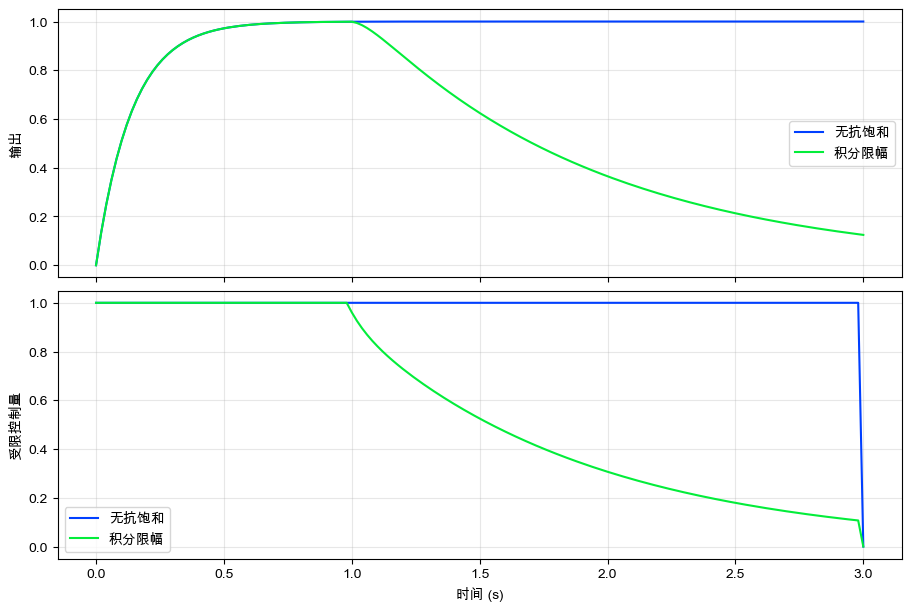

In [5]:
def simulate_pi(anti_windup, dt=0.02, duration=3.0):
    time = np.arange(0, duration + dt, dt)
    output = np.zeros(time.size)
    integral = 0.0
    command = np.zeros(time.size)
    for k, t in enumerate(time[:-1]):
        reference = 5.0 if t < 1.0 else 0.0
        error = reference - output[k]
        integral += error * dt
        if anti_windup:
            integral = float(np.clip(integral, -1.0, 1.0))
        raw_command = 1.0 * error + 2.0 * integral
        command[k] = np.clip(raw_command, -1.0, 1.0)
        output[k + 1] = output[k] + dt * (-output[k] + command[k]) / 0.15
    return time, output, command

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True, constrained_layout=True)
for enabled, label in [(False, "无抗饱和"), (True, "积分限幅")]:
    t, y, u = simulate_pi(enabled)
    axes[0].plot(t, y, label=label)
    axes[1].plot(t, u, label=label)
axes[0].set_ylabel("输出")
axes[1].set_ylabel("受限控制量")
axes[1].set_xlabel("时间 (s)")
for axis in axes:
    axis.grid(True, alpha=0.3)
    axis.legend()
plt.show()


## 6. 低通滤波的收益与代价

一阶离散低通可以写成

$$y_f[k]=\alpha y_f[k-1]+(1-\alpha)y[k]$$

$\alpha$ 越接近 1，曲线越平滑，但延迟越大。对不稳定自行车，过大的滤波延迟可能比噪声本身更危险。滤波参数必须与采样率和控制带宽一起选择。

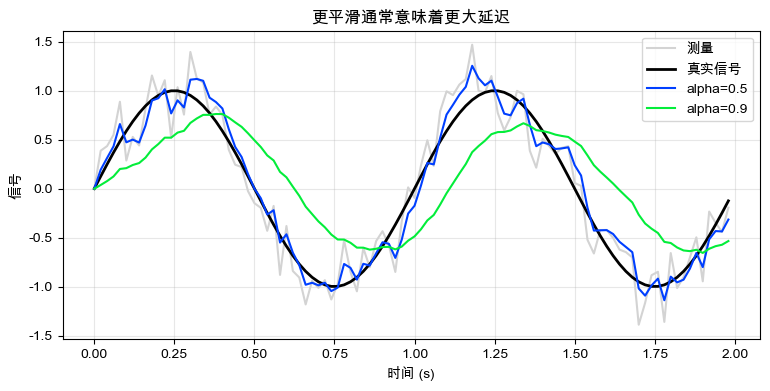

In [6]:
rng = np.random.default_rng(12)
time = np.arange(0, 2.0, 0.02)
truth = np.sin(2 * np.pi * 1.0 * time)
measurement = truth + rng.normal(0, 0.25, time.size)

plt.figure(figsize=(9, 4))
plt.plot(time, measurement, color="lightgray", label="测量")
plt.plot(time, truth, color="black", linewidth=2, label="真实信号")
for alpha in [0.5, 0.9]:
    filtered = np.zeros_like(measurement)
    filtered[0] = measurement[0]
    for k in range(1, time.size):
        filtered[k] = alpha * filtered[k-1] + (1-alpha) * measurement[k]
    plt.plot(time, filtered, label=f"alpha={alpha}")
plt.xlabel("时间 (s)")
plt.ylabel("信号")
plt.title("更平滑通常意味着更大延迟")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 7. 数字实现检查表

在进入 MuJoCo 或真实硬件前，逐项回答：

- 控制器实际更新频率是多少？是否稳定、是否有抖动？
- 时间戳来自固定周期假设，还是每次测量真实间隔？
- 控制命令在两个周期之间怎样保持？
- 传感器有没有滤波，滤波增加多少延迟？
- 执行器的速度、转矩和角度限制是多少？
- PI 积分项如何防止 windup？
- 控制器输出的物理量究竟是角度、角速度还是转矩？

这些问题往往比再把极点向左移动一点更重要。

## 练习

1. 在速度环公式中令 $I=0.002$，分别计算 500 Hz 和 50 Hz 的 $k_p$ 稳定上界。
2. 用 `cont2discrete` 比较 10、50、100 Hz 下的开环离散极点。
3. 改变 PI 仿真的转矩上限，观察 windup 严重程度。
4. 为 50 Hz 信号计算 $\alpha=0.9$ 低通的大致时间常数，并与外环 0.2 s 时间常数比较。
5. 思考：如果电机驱动器内部已经以 1 kHz 完成速度 PI，主控 50 Hz 外环还需要自己重复速度 PI 吗？